In [1]:
# Create a difference map between the activation maps with and without bias for the specified stimulus and SVD value, and save the resulting difference map as a new NIfTI file.

from pathlib import Path
import nibabel as nib

svd_value = 50
stim = "Pinky"
base_path = Path("/Users/clairenastaskin/data/Post_acquisition_parameter_sweep/sub-Forest001/ses-20250708/task-movements_run-001/")
Activation_map_with_bias_path = base_path / f"power_doppler_volumes_200bmodes_1.6s/svd_50/not_subsampled/skateboard_pinky.js_boxcar3_z_map.nii.gz"
Activation_map_without_bias_path = base_path / f"power_doppler_without_biais_200bmodes_1.6s/svd_50/skateboard_pinky.js_boxcar3_z_map.nii.gz"

with_bias_img = nib.load(Activation_map_with_bias_path)
without_bias_img = nib.load(Activation_map_without_bias_path)

Difference_map = with_bias_img.get_fdata() - without_bias_img.get_fdata()

# save Difference_map
Difference_map_path = base_path / "with_without_bias_analysis" / f"{stim}_fingers_svd_{svd_value}_difference_map_with_without_bias.nii.gz"
Difference_map_img = nib.Nifti1Image(Difference_map, with_bias_img.affine, with_bias_img.header)
nib.save(Difference_map_img, Difference_map_path)


Number of significant pixels (z > 3.1): 7208

Significant pixels (z > 3.1):
  Mean activation (with bias): 4.0035
  Mean difference (with - without): -0.0024
  Mean percentage difference: -0.06%
  Median percentage difference: -0.06%
  Min percentage difference: -2.73%
  Max percentage difference: 2.70%


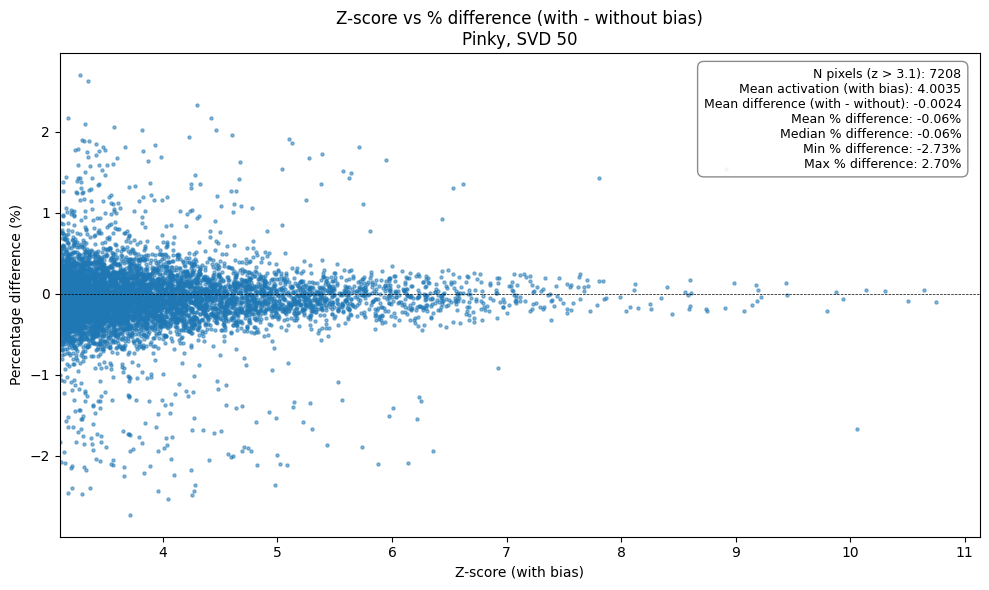

In [2]:
# Select pixels with significant z-score (> 3.1) in Activation_map_with_bias.
# Look at the corresponding values in Difference_map and calculate the percentage of difference.

import numpy as np
import matplotlib.pyplot as plt

Activation_map_with_bias = with_bias_img.get_fdata()

# Mask for significant pixels
significant_mask = Activation_map_with_bias > 3.1

print(f"Number of significant pixels (z > 3.1): {np.sum(significant_mask)}")

# Get values at those pixels
sig_activation_values = Activation_map_with_bias[significant_mask]
sig_difference_values = Difference_map[significant_mask]

# Calculate percentage difference: (difference / with_bias) * 100
percentage_difference = (sig_difference_values / sig_activation_values) * 100

print(f"\nSignificant pixels (z > 3.1):")
print(f"  Mean activation (with bias): {np.mean(sig_activation_values):.4f}")
print(f"  Mean difference (with - without): {np.mean(sig_difference_values):.4f}")
print(f"  Mean percentage difference: {np.mean(percentage_difference):.2f}%")
print(f"  Median percentage difference: {np.median(percentage_difference):.2f}%")
print(f"  Min percentage difference: {np.min(percentage_difference):.2f}%")
print(f"  Max percentage difference: {np.max(percentage_difference):.2f}%")

# Scatter plot: z-score vs percentage difference
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sig_activation_values, percentage_difference, s=5, alpha=0.5)
ax.set_xlabel("Z-score (with bias)")
ax.set_ylabel("Percentage difference (%)")
ax.set_title(f"Z-score vs % difference (with - without bias)\n{stim}, SVD {svd_value}")
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
ax.set_xlim(left=3.1)

# Add statistics text box on the graph
stats_text = (
    f"N pixels (z > 3.1): {np.sum(significant_mask)}\n"
    f"Mean activation (with bias): {np.mean(sig_activation_values):.4f}\n"
    f"Mean difference (with - without): {np.mean(sig_difference_values):.4f}\n"
    f"Mean % difference: {np.mean(percentage_difference):.2f}%\n"
    f"Median % difference: {np.median(percentage_difference):.2f}%\n"
    f"Min % difference: {np.min(percentage_difference):.2f}%\n"
    f"Max % difference: {np.max(percentage_difference):.2f}%"
)
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

plt.tight_layout()

# Save graph
save_dir = base_path / "with_without_bias_analysis"
save_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(save_dir / f"{stim}_svd_{svd_value}_zscore_vs_pct_difference.png", dpi=150, bbox_inches="tight")
plt.show()